In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Configurações 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Reproducibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [9]:
df = pd.read_csv('../data/raw/creditcard.csv')

# Estatísticas descritivas gerais
print(f"Shape: {df.shape}")
print(f"\n Estatísticas descritivas (Time, Amount, Class): ")
print(df[['Time', 'Amount', 'Class']].describe().round(2))

Shape: (284807, 31)

 Estatísticas descritivas (Time, Amount, Class): 
            Time     Amount      Class
count  284807.00  284807.00  284807.00
mean    94813.86      88.35       0.00
std     47488.15     250.12       0.04
min         0.00       0.00       0.00
25%     54201.50       5.60       0.00
50%     84692.00      22.00       0.00
75%    139320.50      77.16       0.00
max    172792.00   25691.16       1.00


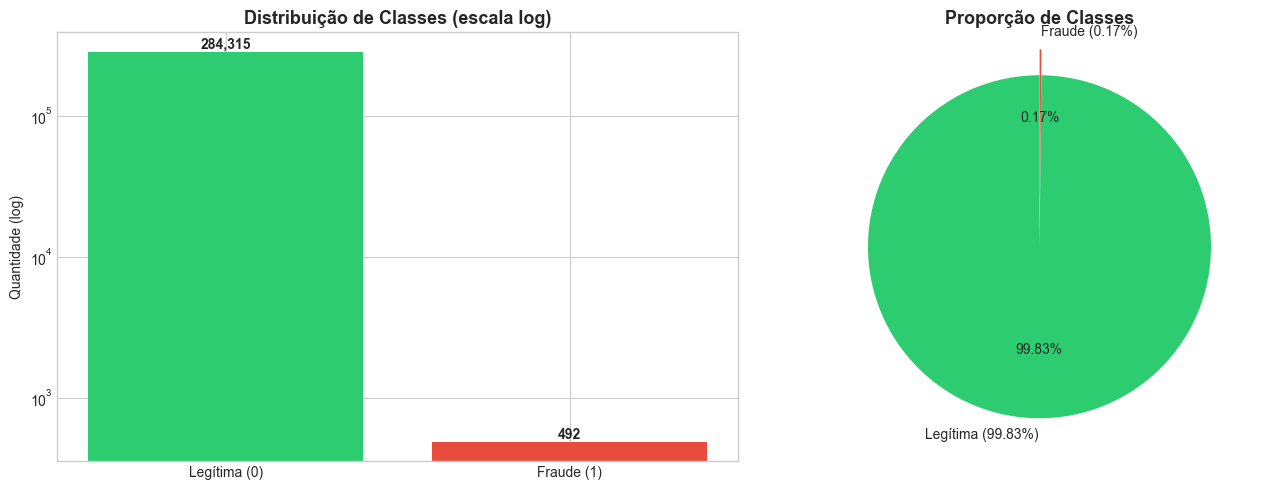

In [13]:
# Distribuição das classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# subplot 1: Contagem absoluta (escala log para enxergar fraudes)
class_counts = df['Class'].value_counts()
axes[0].bar(['Legítima (0)', 'Fraude (1)'], class_counts.values, color = ['#2ecc71', '#e74c3c'])
axes[0].set_yscale('log')
axes[0].set_title('Distribuição de Classes (escala log)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade (log)')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
# Subplot 2: Proporção percentual
class_pct = df['Class'].value_counts(normalize=True) * 100
axes[1].pie(class_pct.values, labels=['Legítima (99.83%)', 'Fraude (0.17%)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%', startangle=90,
            explode=(0, 0.15))
axes[1].set_title('Proporção de Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

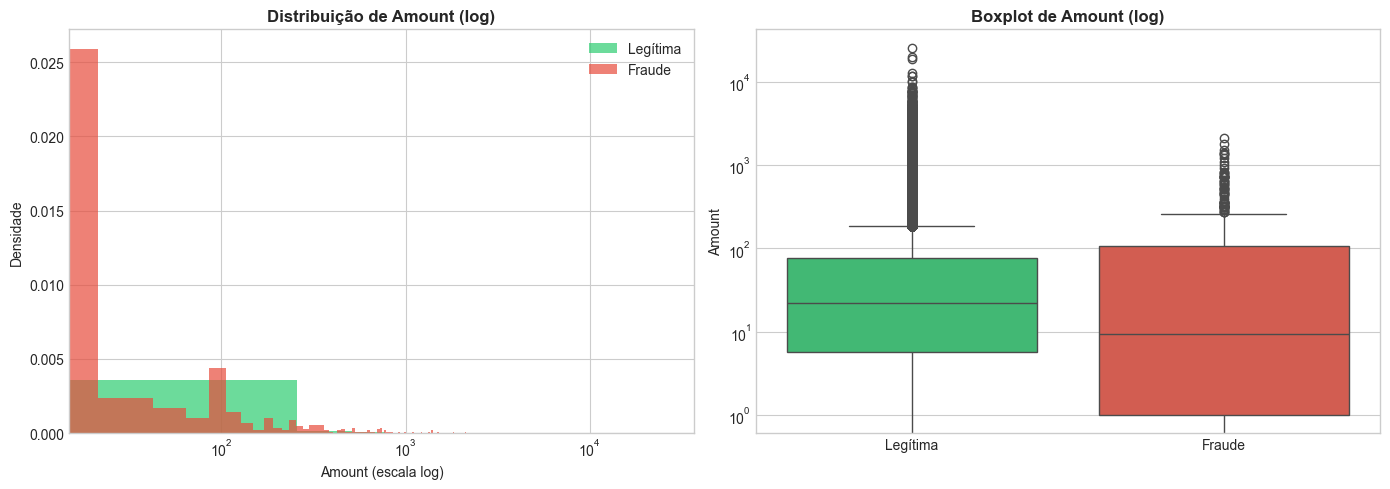


 Mediana Amount — Legítima: R$ 22.00
 Mediana Amount — Fraude: R$ 9.25


In [15]:
# Análise de Amount — Distribuições
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Distribuição geral (escala log)
axes[0].hist(df[df['Class'] == 0]['Amount'], bins=100, alpha=0.7,
             label='Legítima', color='#2ecc71', density=True)
axes[0].hist(df[df['Class'] == 1]['Amount'], bins=100, alpha=0.7,
             label='Fraude', color='#e74c3c', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Amount (escala log)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição de Amount (log)', fontweight='bold')
axes[0].legend()

# Subplot 2: Boxplot comparativo
df_plot = df.copy()
df_plot['Class_label'] = df_plot['Class'].map({0: 'Legítima', 1: 'Fraude'})
sns.boxplot(data=df_plot, x='Class_label', y='Amount', hue='Class_label', ax=axes[1],
            palette={'Legítima': '#2ecc71', 'Fraude': '#e74c3c'}, legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Boxplot de Amount (log)', fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print(f"\n Mediana Amount — Legítima: R$ {df[df['Class']==0]['Amount'].median():.2f}")
print(f" Mediana Amount — Fraude: R$ {df[df['Class']==1]['Amount'].median():.2f}")

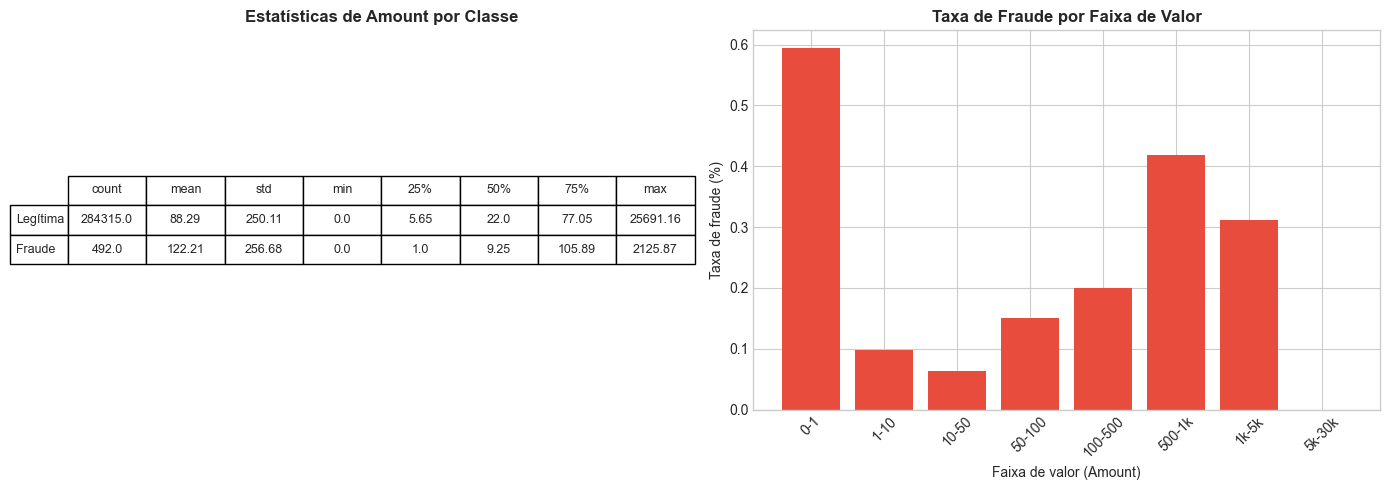

 Quantidade de fraudes com Amount = 0: 27
 Quantidade de legítimas com Amount = 0: 1798


In [16]:
# Análise de Amount — Estatísticas e Risco
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Estatísticas comparativas
stats_df = df.groupby('Class')['Amount'].describe().round(2)
stats_df.index = ['Legítima', 'Fraude']
axes[0].axis('off')
table = axes[0].table(cellText=stats_df.values,
                      rowLabels=stats_df.index,
                      colLabels=stats_df.columns,
                      loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
axes[0].set_title('Estatísticas de Amount por Classe', fontweight='bold')

# Subplot 2: Faixa de valores - onde estão as fraudes?
bins = [0, 1, 10, 50, 100, 500, 1000, 5000, 30000]
labels = ['0-1', '1-10', '10-50', '50-100', '100-500', '500-1k', '1k-5k', '5k-30k']
df['Amount_bin'] = pd.cut(df['Amount'], bins=bins, labels=labels, include_lowest=True)
fraud_rate_by_bin = df.groupby('Amount_bin', observed=True)['Class'].mean() * 100
axes[1].bar(range(len(fraud_rate_by_bin)), fraud_rate_by_bin.values, color='#e74c3c')
axes[1].set_xticks(range(len(fraud_rate_by_bin)))
axes[1].set_xticklabels(fraud_rate_by_bin.index, rotation=45)
axes[1].set_xlabel('Faixa de valor (Amount)')
axes[1].set_ylabel('Taxa de fraude (%)')
axes[1].set_title('Taxa de Fraude por Faixa de Valor', fontweight='bold')

plt.tight_layout()
plt.show()

print(f" Quantidade de fraudes com Amount = 0: {((df['Class']==1) & (df['Amount']==0)).sum()}")
print(f" Quantidade de legítimas com Amount = 0: {((df['Class']==0) & (df['Amount']==0)).sum()}")

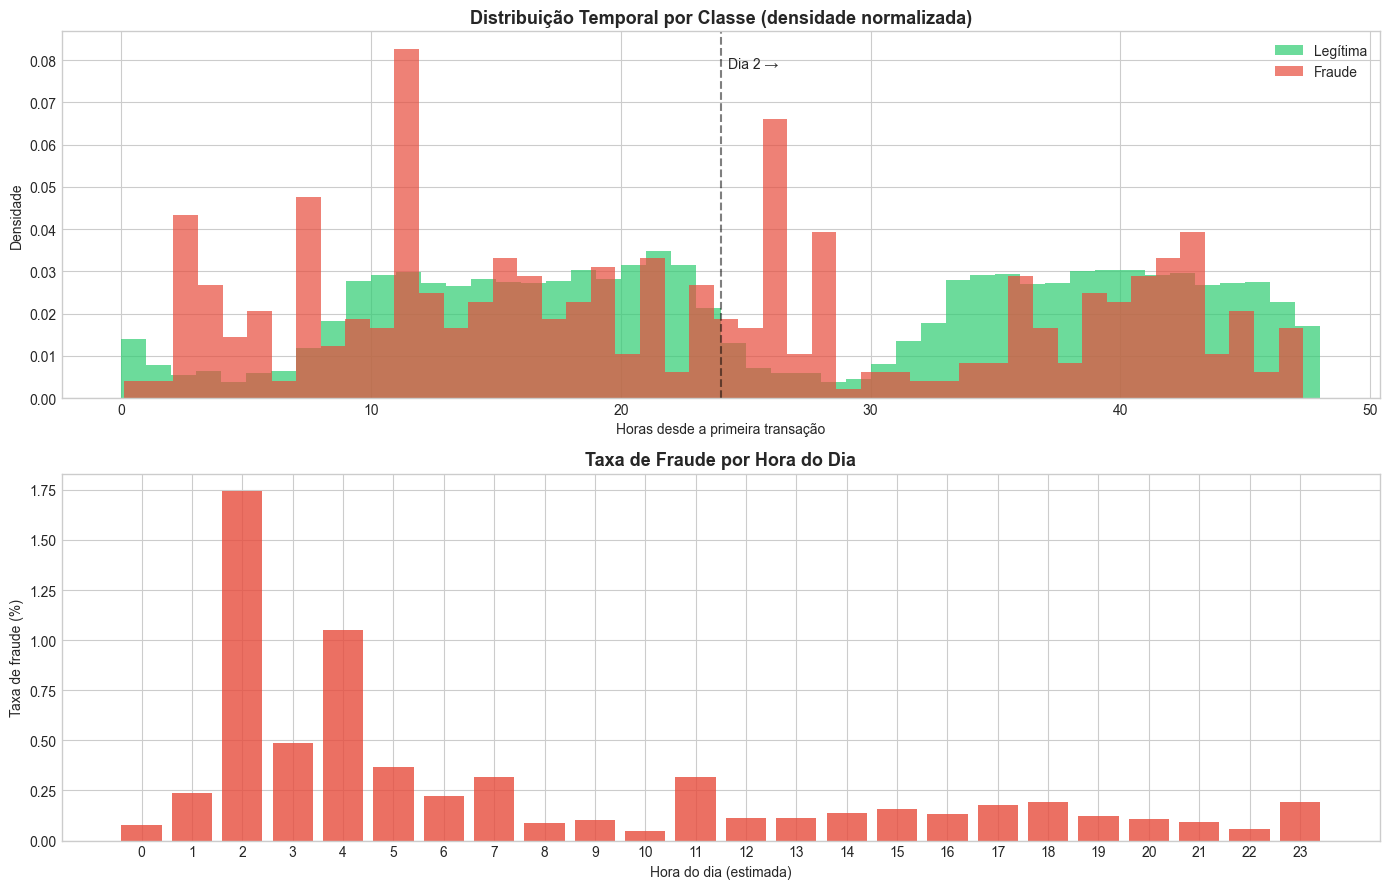


 Hora com maior taxa de fraude: 2h (1.743%)
 Hora com menor taxa de fraude: 10h (0.048%)


In [17]:
# Converter Time para HORAS ===
df['Hour'] = (df['Time'] / 3600) % 24  # Hora do dia (0-24)

# === DISTRIBUIÇÃO TEMPORAL ===
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Subplot 1: Distribuição absoluta de Time
axes[0].hist(df[df['Class'] == 0]['Time'] / 3600, bins=48, alpha=0.7, 
             label='Legítima', color='#2ecc71', density=True)
axes[0].hist(df[df['Class'] == 1]['Time'] / 3600, bins=48, alpha=0.7,
             label='Fraude', color='#e74c3c', density=True)
axes[0].set_xlabel('Horas desde a primeira transação')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição Temporal por Classe (densidade normalizada)', 
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].axvline(x=24, color='black', linestyle='--', alpha=0.5, label='Fim do dia 1')
axes[0].text(24.3, axes[0].get_ylim()[1]*0.9, 'Dia 2 →', fontsize=10)

# Subplot 2: Distribuição por hora do dia
hour_fraud = df[df['Class'] == 1].groupby(df[df['Class'] == 1]['Hour'].astype(int)).size()
hour_legit = df[df['Class'] == 0].groupby(df[df['Class'] == 0]['Hour'].astype(int)).size()
hour_fraud_pct = hour_fraud / hour_legit * 100  # taxa de fraude por hora

axes[1].bar(hour_fraud_pct.index, hour_fraud_pct.values, color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Hora do dia (estimada)')
axes[1].set_ylabel('Taxa de fraude (%)')
axes[1].set_title('Taxa de Fraude por Hora do Dia', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

print(f"\n Hora com maior taxa de fraude: {hour_fraud_pct.idxmax()}h ({hour_fraud_pct.max():.3f}%)")
print(f" Hora com menor taxa de fraude: {hour_fraud_pct.idxmin()}h ({hour_fraud_pct.min():.3f}%)")